# Supplementary Exercises

```{warning}
This page contains solutions! We recommend attempting each problem before peeking.
```

## 1. Beetles (Bliss Data)
In his 1935 paper, Bliss provides a table showing a number of flour beetles killed after 5 hours of exposure to gaseous carbon disulfide at various concentrations. This data set has since been used extensively by statisticians to illustrate and compare models for binary and binomial data.

Use logistic regression on the following data:

``` python
x = np.array([1.6907, 1.7242, 1.7552, 1.7842, 1.8113, 1.8369, 1.8610, 1.8839])
n = np.array([59, 60, 62, 56, 63, 59, 62, 60])
y = np.array([6, 13, 18, 28, 52, 53, 61, 60])
```

Use one of the logit, probit, cloglog, loglog, or cauchyit link functions.

```{admonition} Solution
:class: tip, dropdown

The logistic regression model will look like this:

\begin{align*}
y_i | \boldsymbol{\beta}, \mathbf{x}_i &\sim \text{Binomial}(n_i, p_i) \\
g(p_i) &= \beta_0 + \sum_{j=1}^p \beta_j x_{ij} \\
\beta_0 &\sim \mathcal{N}(0, \sigma_0^2) \\
\beta_j &\sim \mathcal{N}(0, \sigma^2), \quad j = 0, 1, \ldots, p
\end{align*}

where $g(\cdot)$ is the link function.

**For logit:**

$$
\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)
$$

and its inverse $g^{-1}(\cdot)$ is the logistic function:

$$
\text{logistic}(x) = \frac{1}{1 + e^{-x}}
$$

**For probit:**

$$
\text{probit}(p) = \Phi^{-1}(p)
$$

where $\Phi$ is the cumulative distribution function of the standard normal distribution:

$$
\Phi(x) = \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]
$$

$\text{erf}$ is the error function:

$$
\text{erf}(x) = \frac{2}{\sqrt{\pi}} \int_0^x e^{-t^2} \, dt
$$

**For cloglog (complementary log-log):**

$$
\text{cloglog}(p) = \log(-\log(1 - p))
$$

and its inverse $g^{-1}(\cdot)$ is:

$$
g^{-1}(x) = 1 - e^{-e^x}
$$

**For loglog:**

$$
\text{loglog}(p) = -\log(-\log(p))
$$

and its inverse $g^{-1}(\cdot)$ is:

$$
g^{-1}(x) = e^{-e^{-x}}
$$

**For cauchyit:**

$$
\text{cauchyit}(p) = \tan\left(\pi \left(p - \frac{1}{2}\right)\right)
$$

and its inverse $g^{-1}(\cdot)$ is:

$$
g^{-1}(x) = \frac{1}{2} + \frac{1}{\pi} \arctan(x)
$$

```

In [16]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import exp, invlogit, invprobit, arctan


# Complementary log-log transformation
def invcloglog(x):
    return 1 - exp(-exp(x))


# Log-log transformation
def invloglog(x):
    return exp(-exp(-x))


# Cauchit transformation
def invcauchit(x):
    return 0.5 + (1 / np.pi) * arctan(x)


x = np.array([1.6907, 1.7242, 1.7552, 1.7842, 1.8113, 1.8369, 1.8610, 1.8839])
n = np.array([59, 60, 62, 56, 63, 59, 62, 60])
y = np.array([6, 13, 18, 28, 52, 53, 61, 60])

with pm.Model() as m:
    x_data = pm.MutableData("concentration", x)

    beta0 = pm.Normal("beta0", 0, 100)
    beta1 = pm.Normal("beta1", 0, 100)

    # Uncomment desired link function
    p = invlogit(beta0 + beta1 * x_data)  # logit
    # p = invprobit(beta0 + beta1 * x_data)  # probit
    # p = invcloglog(beta0 + beta1 * x_data)  # cloglog
    # p = invloglog(beta0 + beta1 * x_data)  # loglog
    # p = invcauchit(beta0 + beta1 * x_data)  # cauchyit

    pm.Binomial("likelihood", n=n, p=p, observed=y)

    trace = pm.sample(5000)

az.summary(trace, kind="stats")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 11 seconds.


,mean,sd,hdi_3%,hdi_97%
beta0,-60.962,5.224,-70.699,-51.333
beta1,34.408,2.937,29.094,39.977



## 2. Vasoconstriction
The data give the presence or absence ($y_i = 1$ or $0$) of vasoconstriction in the skin of the fingers following inhalation of a certain volume of air ($v_i$) at a certain average rate ($r_i$). Total number of records is 39. The candidate models for analyzing the relationship are the usual logit, probit, cloglog, loglog, and cauchyit models.

Data is available for download in csv format [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/vasoconstriction.csv).

1. Transform covariates $v$ and $r$ as:

$$
x_1 = \log(10 \times v), \quad x_2 = \log(10 \times r)
$$

2. Using a PPL, estimate posterior means for coefficients in the logit model. Use noninformative priors on all coefficients.

3. For a subject with $v = r = 1.5$, find the probability of vasoconstriction.

4. Which of the five links: logit, probit, cloglog, loglog, and cauchyit, has the smallest deviance? An example for use of the five links is in Question 1, above. Uncomment and run one link at a time.

```{admonition} Solution
:class: tip, dropdown

This is a standard logistic regression model, see code cell below.

```





In [2]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import dot, invlogit, invprobit, log, sum, exp, arctan

#Read data and transform x's
data=pd.read_csv("../data/vasoconstriction.csv")
data['x1'] = np.log(10*data['v'])
data['x2'] = np.log(10*data['r'])

# Complementary log-log transformation
def invcloglog(x):
    return 1 - exp(-exp(x))

# Log-log transformation
def invloglog(x):
    return exp(-exp(-x))

# Cauchit transformation
def invcauchit(x):
    return 0.5 + (1 / np.pi) * arctan(x)

# New data point
new_data = np.array([[np.log(10*1.5),np.log(10*1.5)]])

with pm.Model() as m:
    #Data
    X_data = pm.Data("X_data", data[['x1','x2']])
    y_data = pm.Data("y_data", data['y'])

    #Coefficient priors
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    betas = pm.Normal("beta", mu=0, sigma=1000, shape=X_data.shape[1])

    #Bernoulli Regression
    p = invlogit(alpha + dot(X_data, betas))
    # p = invprobit(alpha + dot(X_data, betas))
    # p = invcloglog(alpha + dot(X_data, betas))
    # p = invloglog(alpha + dot(X_data, betas))
    # p = invcauchit(alpha + dot(X_data, betas))

    #Likelihood
    pm.Bernoulli("y", p=p, observed=y_data)

    #Deviance
    f = pm.Deterministic("f", p**y_data * (1-p)**(1-y_data))
    loglik = pm.Deterministic("loglik", log(f))
    pm.Deterministic("deviance", -2 * sum(loglik))

    #mean prediction
    p_new = pm.Deterministic('p_new',invlogit(alpha + dot(new_data, betas)))

    trace = pm.sample(5000)


az.summary(trace,var_names=['alpha','beta','deviance','p_new'])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-4.417,3.104,-10.540,1.201,0.041,0.032,5745.0,6215.0,1.0
beta[0],0.797,0.736,-0.538,2.214,0.009,0.007,6276.0,7531.0,1.0
beta[1],0.974,0.682,-0.380,2.190,0.009,0.007,6434.0,7094.0,1.0
deviance,54.719,2.586,51.534,59.465,0.033,0.033,6476.0,8247.0,1.0
p_new[0],0.590,0.092,0.420,0.760,0.001,0.001,14032.0,14217.0,1.0


## 3. Caesarean Delivery: Categorical Response
Table 1 contains grouped data on infection of mothers after a C-section, collected at the Clinical Center of the University of Munich. The response variable has three categories: Infection of type I, Infection of type II, and No infection. For each mother three covariates are collected:

\begin{align*}
\text{NOPLAN} &= 
\begin{cases} 
1 & \text{C-section was not planned} \\
0 & \text{Planned} 
\end{cases} \\
\text{RISK} &= 
\begin{cases} 
1 & \text{Risk factors present} \\
0 & \text{No risk factors} 
\end{cases} \\
\text{ANTIB} &= 
\begin{cases} 
1 & \text{Antibiotics given as prophylaxis} \\
0 & \text{No antibiotics given} 
\end{cases}
\end{align*}

1. Given the covariates, establish a multinomial model, where the outcome "No infection" serves as a baseline.

$$
\text{Table 1: Data on infections for 251 C-sections.}
$$

$$
\begin{array}{|l|lll|lll|}
\hline
& \rlap{\text{Planned}} & & & \rlap{\text{Unplanned}} & & \\
\text{Infection} & \text{I} & \text{II} & \text{No} & \text{I} & \text{II} & \text{No} \\
\hline
\textbf{Antibiotics} & & & & & & \\
\hspace{1em}\text{Risk factor} & 0 & 1 & 17 & 4 & 7 & 87 \\
\hspace{1em}\text{No risk factor} & 0 & 0 & 2 & 0 & 0 & 0 \\
\hline
\textbf{No Antibiotics} & & & & & & \\
\hspace{1em}\text{Risk factor} & 11 & 17 & 30 & 10 & 13 & 3 \\
\hspace{1em}\text{No risk factor} & 4 & 4 & 32 & 0 & 0 & 9 \\
\hline
\end{array}
$$


1. A new C-section delivery for a mother with covariates $(\text{NOPLAN}, \text{RISK}, \text{ANTIBIO}) = (1, 0, 0)$ is to be evaluated for risks of infection. What are the estimated probabilities of no infection, and type I and II infections?

Hint: Consult [](Unit7-demo-multinomial.ipynb).


```{admonition} Solution
:class: tip, dropdown

See hidden code cell below!

```

In [3]:
import pymc as pm
import arviz as az
import numpy as np
import pytensor.tensor as pt

# y columns: infection I, infection II, No infection
y = np.array([[ 0,  1, 17],
              [ 0,  0,  2],
              [11, 17, 30],
              [ 4,  4, 32],
              [ 4,  7, 87],
              [ 0,  0,  0],
              [10, 13,  3],
              [ 0,  0, 9]])

# X columns: planned, risk, antibiotics
X = np.array([[0, 1, 1],
              [0, 0, 1],
              [0, 1, 0],
              [0, 0, 0],
              [1, 1, 1],
              [1, 0, 1],
              [1, 1, 0],
              [1, 0, 0]])

# add intercept to X
X_aug = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
N, P = X_aug.shape
K = y.shape[1]

# new data point, with intercept
new_data = np.array([[1,1,0,0]])


with pm.Model() as m:
    y_data = pm.Data("y", y)
    X_data = pm.Data("X", X_aug)

    _beta = pm.Normal("_beta", mu=0, tau=0.1, shape=(P, K - 1))
    beta = pt.concatenate([_beta, pt.zeros((P, 1))], axis=1)

    eta = pm.math.dot(X_data, beta)
    p = pm.math.softmax(eta, axis=1)

    pm.Multinomial("likelihood", n=pm.math.sum(y_data,axis=1), p=p, observed=y_data, shape=X_data.shape)

    eta_new = pm.math.dot(new_data, beta)
    p_new = pm.Deterministic("p_new",pm.math.softmax(eta_new))

    trace = pm.sample(5000)

az.summary(trace,var_names="p_new")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [_beta]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"p_new[0, 0]",0.168,0.081,0.034,0.316,0.001,0.001,18419.0,14042.0,1.0
"p_new[0, 1]",0.151,0.074,0.031,0.290,0.001,0.001,17537.0,13421.0,1.0
"p_new[0, 2]",0.681,0.101,0.487,0.860,0.001,0.001,16087.0,14936.0,1.0


## 4. Magnesium Ammonium Phosphate and Chrysanthemums
Walpole et al. (2007) provide data from a study on the effect of magnesium ammonium phosphate on the height of chrysanthemums, which was conducted at George Mason University in order to determine a possible optimum level of fertilization, based on the enhanced vertical growth response of the chrysanthemums. Forty chrysanthemum seedlings were assigned to 4 groups, each containing 10 plants. Each was planted in a similar pot containing a uniform growth medium. An increasing concentration of $\text{MgNH}_4\text{PO}_4$, measured in grams per bushel, was added to each plant. The 4 groups of plants were grown under uniform conditions in a greenhouse for a period of 4 weeks. The treatments and the respective changes in heights, measured in centimeters, are given in the following table:

Data is available for download in csv format [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/chrysanthemums.csv).

Solve the problem as a Bayesian one-way ANOVA. Use STZ constraints on treatment effects.

1. Do different concentrations of $\text{MgNH}_4\text{PO}_4$ affect the average attained height of chrysanthemums? Look at the 95% credible sets for the differences between treatment effects.

2. Find the 95% credible set for the contrast $\mu_1 - \mu_2 - \mu_3 + \mu_4$.


```{admonition} Solution
:class: tip, dropdown

Solution in hidden code cell below!


```

In [2]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

data = pd.read_csv("../data/chrysanthemums.csv")

with pm.Model() as m:
    mu0 = pm.Normal("mu_0", mu=0, tau=0.0001)
    tau = pm.Gamma("tau", 0.001, 0.001)

    alpha = pm.ZeroSumNormal("alpha", sigma=10, shape=4)

    mu_1 = mu0 + alpha[0]
    mu_2 = mu0 + alpha[1]
    mu_3 = mu0 + alpha[2]
    mu_4 = mu0 + alpha[3]

    pm.Normal("lik1", mu=mu_1, tau=tau, observed=data['50 g/bu'])
    pm.Normal("lik2", mu=mu_2, tau=tau, observed=data['100 g/bu'])
    pm.Normal("lik3", mu=mu_3, tau=tau, observed=data['200 g/bu'])
    pm.Normal("lik4", mu=mu_4, tau=tau, observed=data['400 g/bu'])

    onetwo = pm.Deterministic("α1-α2", alpha[0] - alpha[1])
    onethree = pm.Deterministic("α1-α3", alpha[0] - alpha[2])
    onefour = pm.Deterministic("α1-α4", alpha[0] - alpha[3])
    twothree = pm.Deterministic("α2-α3", alpha[1] - alpha[2])
    twofour = pm.Deterministic("α2-α4", alpha[1] - alpha[3])
    threefour = pm.Deterministic("α3-α4", alpha[2] - alpha[3])

    part2_contrast = pm.Deterministic(
        "α1-α2-α3+α4",alpha[0] - alpha[1] - alpha[2] + alpha[3])

    trace = pm.sample(5000)

az.summary(trace,hdi_prob=.95,var_names="α",filter_vars="like")



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, tau, alpha]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1 seconds.


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α1-α2,-1.763,1.930,-5.592,2.051,0.012,0.015,24598.0,16179.0,1.0
α1-α2-α3+α4,-0.008,2.715,-5.169,5.509,0.017,0.019,25733.0,16460.0,1.0
α1-α3,-2.898,1.922,-6.653,0.882,0.012,0.013,24965.0,16269.0,1.0
α1-α4,-4.654,1.933,-8.376,-0.661,0.013,0.014,23781.0,15967.0,1.0
α2-α3,-1.135,1.919,-4.990,2.577,0.012,0.014,25021.0,15434.0,1.0
α2-α4,-2.891,1.923,-6.658,0.919,0.012,0.013,25790.0,16808.0,1.0
α3-α4,-1.755,1.916,-5.398,2.094,0.012,0.014,25481.0,16242.0,1.0


array([<Axes: >], dtype=object)

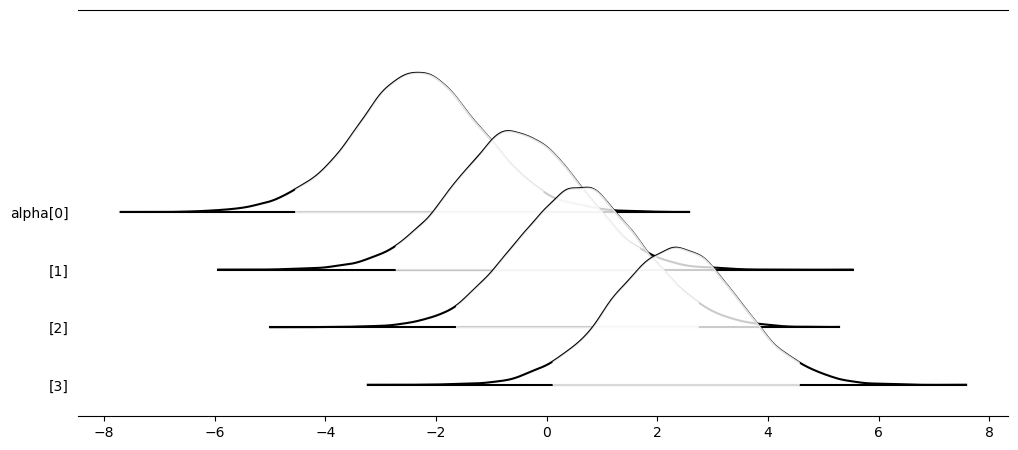

In [3]:
az.plot_forest(trace,var_names='alpha',
        kind="ridgeplot",combined=True,
        ridgeplot_truncate=False,
        ridgeplot_overlap=2,
        ridgeplot_alpha=0.8,
        colors="white")


## 5. Third-degree Burns
The data for this exercise, discussed in Fan et al. (1995), refer to $n = 435$ adults who were treated for third-degree burns by the University of Southern California General Hospital Burn Center. The patients were grouped according to the area of third-degree burns on the body. For each midpoint of the groupings "log(area +1)," the number of patients in the corresponding group who survived and the number who died from the burns was recorded:

$$
\begin{array}{|c|c|c|}
\hline
\text{Log(area+1)} & \text{Survived} & \text{Died} \\
\hline
1.35 & 13 & 0 \\
1.60 & 19 & 0 \\
1.75 & 67 & 2 \\
1.85 & 45 & 5 \\
1.95 & 71 & 8 \\
2.05 & 50 & 20 \\
2.15 & 35 & 31 \\
2.25 & 7 & 49 \\
2.35 & 1 & 12 \\
\hline
\end{array}
$$

Data is available for download in csv format [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/thirddegreeburns.csv).

1. Fit the logistic regression on the probability of death due to third-degree burns with the covariate $x = \log(\text{area} + 1)$. What is the deviance?

2. Using your model, estimate the posterior probability of survival for a person for whom $\log(\text{area} + 1)$ equals 2.

3. Repeat (a) with probit and complementary log-log links. In terms of deviance, which model provides the best fit?


```{admonition} Solution
:class: tip, dropdown

Two version of a solutions are provided using a (1) binomial or (2) Bernoulli likelihood.

```

In [4]:
# Binomial version of solution

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import dot, invlogit, invprobit, log, sum, exp
from scipy.special import factorial

def binom_coeff(n,k):
    return factorial(n) / (factorial(k)*factorial(n-k))

#read data, and calculate n and binomial coefficienct for each row
data = pd.read_csv("../data/thirddegreeburns.csv")
data['n'] = data['Survived'] + data['Died']
data['binom_coeff'] = binom_coeff(data['n'],data['Survived'])

# Log-log transformation
def invloglog(x):
    return exp(-exp(-x))

with pm.Model() as m:
    #Data
    X_data = pm.Data("X_data", data['Log(area+1)'])
    y_data = pm.Data("y_data", data['Survived'])
    n_data = pm.Data("n_data", data['n'])
    binom_coef_data = pm.Data("binom_coef_data", data['binom_coeff'])

    #Coefficient priors
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000)

    #Regression
    # p = invlogit(alpha + dot(X_data, beta))
    # p = invprobit(alpha + dot(X_data, beta))
    p = invloglog(alpha + dot(X_data, beta))

    #Likelihood
    pm.Binomial("y", p=p, n=n_data, observed=y_data)

    #Deviance
    f = pm.Deterministic("f",binom_coef_data * (p**y_data * (1-p)**(n_data-y_data)))
    loglik = pm.Deterministic("loglik", log(f))
    pm.Deterministic("deviance", -2 * sum(loglik))

    #mean prediction
    p_new = pm.Deterministic('p_new',invlogit(alpha + 2 * beta))

    trace = pm.sample(5000)

    # another way to find loglik, to check formula above
    # ll = pm.compute_log_likelihood(trace)

az.summary(trace, var_names=['alpha','beta','deviance','p_new'])



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,18.187,1.607,15.307,21.329,0.029,0.022,3096.0,3428.0,1.0
beta,-8.313,0.749,-9.749,-6.939,0.013,0.010,3091.0,3428.0,1.0
deviance,32.181,2.012,30.167,35.899,0.030,0.040,5505.0,5242.0,1.0
p_new,0.826,0.020,0.787,0.863,0.000,0.000,4874.0,6137.0,1.0


In [5]:
# Binomial version of solution

# First, expand the data to a long format,
# where each row corresponds to a single observation (either survived or died).

data_long = []
for i in range(len(data)):
    for j in range(int(data.iloc[i]['Survived'])):
        data_long.append([data.iloc[i]['Log(area+1)'],1])
    for j in range(int(data.iloc[i]['Died'])):
        data_long.append([data.iloc[i]['Log(area+1)'],0])

data_long = pd.DataFrame(data_long)
data_long.rename(columns={0:"Log(area+1)",1:"Survived"},inplace=True)

with pm.Model() as m:
    #Data
    X_data = pm.Data("X_data", data_long['Log(area+1)'])
    y_data = pm.Data("y_data", data_long['Survived'])

    #Coefficient priors
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000)

    #Bernoulli Regression
    # p = invlogit(alpha + dot(X_data, beta))
    # p = invprobit(alpha + dot(X_data, beta))
    p = invloglog(alpha + dot(X_data, beta))

    #Likelihood
    pm.Bernoulli("y", p=p, observed=y_data)

    #Deviance
    f = pm.Deterministic("f", p**y_data * (1-p)**(1-y_data))
    loglik = pm.Deterministic("loglik", log(f))
    pm.Deterministic("deviance", -2 * sum(loglik))

    #mean prediction
    p_new = pm.Deterministic('p_new',invlogit(alpha + 2 * beta))    

    trace = pm.sample(5000)

az.summary(trace,var_names = ['alpha','beta','deviance'])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 4 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,18.145,1.622,15.017,21.159,0.030,0.022,2986.0,3249.0,1.0
beta,-8.293,0.757,-9.731,-6.855,0.014,0.010,2987.0,3271.0,1.0
deviance,334.323,2.056,332.302,338.083,0.032,0.041,5194.0,5175.0,1.0


## 6. Shocks!
An experiment was conducted to assess the effect of small electrical currents on farm animals, with the eventual goal of understanding the effects of high-voltage powerlines on livestock. The experiment was carried out with seven cows, and six shock intensities, 0, 1, 2, 3, 4, and 5 milliamps (shocks on the order of 15 milliamps are painful for many humans). Each cow was given 30 shocks, five at each intensity, in random order. The entire experiment was then repeated, so each cow received a total of 60 shocks. For each shock the response, mouth movement, was either present or absent. The data as quoted give the total number of responses, out of 70 trials, at each shock level. We ignore cow differences and differences between blocks (experiments).

$$
\begin{array}{|c|c|c|c|}
\hline
\text{Current (ma)} & y & \text n & p \\
\hline
0 & 0 & 70 & 0.000 \\
1 & 9 & 70 & 0.129 \\
2 & 21 & 70 & 0.300 \\
3 & 47 & 70 & 0.671 \\
4 & 60 & 70 & 0.857 \\
5 & 63 & 70 & 0.900 \\
\hline
\end{array}
$$

Here, $y$ is the number of responses, $n$ is the number of trials, and $p$ is the proportion of responses.

Data is available for download in csv format [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/shocks.csv).

As in the exercise on beetles (bliss data), model $y$ as a function of $x$ via binary regression with 5 different links and propose the link that minimizes the deviance.


```{admonition} Solution
:class: tip, dropdown

Expand the hidden code cell below!

```

In [6]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import dot, invlogit, invprobit, log, sum, exp, arctan
from scipy.special import factorial

data = pd.read_csv("../data/shocks.csv")


def binom_coeff(n,k):
    return factorial(n) / (factorial(k)*factorial(n-k))

#read data, and calculate n and binomial coefficienct for each row
data['binom_coeff'] = binom_coeff(data['Number of Trials $n$'],data['Number of Responses $y$'])

# Complementary log-log transformation
def invcloglog(x):
    return 1 - exp(-exp(x))

# Log-log transformation
def invloglog(x):
    return exp(-exp(-x))

# Cauchit transformation
def invcauchit(x):
    return 0.5 + (1 / np.pi) * arctan(x)


with pm.Model() as m:
    #Data
    X_data = pm.Data("X_data", data['Current (milliamps)'])
    y_data = pm.Data("y_data", data['Number of Responses $y$'])
    n_data = pm.Data("n_data", data['Number of Trials $n$'])
    binom_coef_data = pm.Data("binom_coef_data", data['binom_coeff'])

    #Coefficient priors
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000)

    #Regression
    # p = invlogit(alpha + dot(X_data, beta))
    # p = invprobit(alpha + dot(X_data, beta))
    # p = invcloglog(alpha + dot(X_data, beta))
    # p = invloglog(alpha + dot(X_data, beta))
    p = invcauchit(alpha + dot(X_data, beta))

    #Likelihood
    pm.Binomial("y", p=p, n=n_data, observed=y_data)

    #Deviance
    f = pm.Deterministic("f",binom_coef_data * (p**y_data * (1-p)**(n_data-y_data)))
    loglik = pm.Deterministic("loglik", log(f))
    pm.Deterministic("deviance", -2 * sum(loglik))

    trace = pm.sample(5000)

    # another way to find loglik, to check formula above
    # ll = pm.compute_log_likelihood(trace)

az.summary(trace, var_names=['alpha','beta','deviance'])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-4.346,0.686,-5.583,-3.079,0.012,0.009,3483.0,3945.0,1.0
beta,1.676,0.251,1.225,2.144,0.004,0.003,3472.0,3730.0,1.0
deviance,34.877,2.095,32.798,38.519,0.031,0.044,5445.0,6342.0,1.0


## 7. Binary Regression and IOP

Laser refractive surgery often decreases Intraocular Pressure (IOP) and may lead to hypotony (clinically significant low IOP that may lead to corneal decompensation, accelerated cataract formation, maculopathy, and discomfort). An investigator wished to determine whether the post-operative IOP in patients after laser refractive surgery was related to the residual thickness of the cornea. 

In a sample of 140 patients who had undergone laser surgery, post-operative IOP and the thickness of the cornea were measured. The dataset is provided in the startup file `iop2.odc` which consists of two columns: 
- Indicator of low IOP (IOP < 10) 
- Central corneal thickness (in micrometers)

1. Fit the logistic regression with cornea thickness as the predictor of incidence of low IOP.
2. For a person who had a refractive surgery with residual thickness of cornea of 420 micrometers, what is the risk of a low IOP.
3. Compare deviances for two links: logit (as in (a)), and probit. Which link provides better fit?

Data is available for download in csv format [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/iop.csv).



```{admonition} Solution
:class: tip, dropdown

Check out solution in hidden code cell below!

```


In [10]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import dot, invlogit, invprobit, log, sum

def standardize(X_df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize input variables by 2 std dev.

    See https://stat.columbia.edu/~gelman/research/published/standardizing7.pdf.
    """
    # find and store means and std, then standardize
    means = X_df.mean(axis=0)
    stdevs = X_df.std(axis=0)
    X_standardized = (X_df - means) / (2 * stdevs)

    return X_standardized

data = pd.read_csv("../data/iop.csv")

#default NUTS ssampler diverges unless data is standardized. Other samplers work fine with non-standardized data
X_std = standardize(data['Thickness'])

with pm.Model() as m:
    #Data
    # X_data = pm.Data("X_data", X_std)
    X_data = pm.Data("X_data", data['Thickness'])
    y_data = pm.Data("y_data", data['LowIOP'])

    #Coefficient priors
    alpha = pm.Normal("alpha", mu=0, sigma=1000)
    beta = pm.Normal("beta", mu=0, sigma=1000)

    #Bernoulli Regression
    # p = invlogit(alpha + dot(X_data, beta))
    p = invprobit(alpha + dot(X_data, beta))

    #Likelihood
    pm.Bernoulli("y", p=p, observed=y_data)

    #Deviance
    f = pm.Deterministic("f", p**y_data * (1-p)**(1-y_data))
    loglik = pm.Deterministic("loglik", log(f))
    pm.Deterministic("deviance", -2 * sum(loglik))

    #mean prediction
    p_new = pm.Deterministic('p_new',invlogit(alpha + 420 * beta))    


    # trace = pm.sample(5000)
    # trace = pm.sample(5000,nuts_sampler="numpyro")
    # trace = pm.sample(5000,nuts_sampler="blackjax")
    trace = pm.sample(5000,nuts_sampler="nutpie")

az.summary(trace,var_names = ['alpha','beta','deviance'])

Progress,Draws,Divergences,Step Size,Gradients/Draw
,6000,0,0.27,23
,6000,0,0.26,43
,6000,0,0.26,31
,6000,0,0.28,3


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,7.409,1.831,4.024,10.885,0.035,0.024,2780.0,3368.0,1.0
beta,-0.017,0.004,-0.024,-0.010,0.000,0.000,2786.0,3344.0,1.0
deviance,134.042,1.976,132.053,137.704,0.030,0.036,5297.0,5275.0,1.0


## 8. Negative Binomial as a Gamma Mixture of Poissons

Implement this model, which recreates a negative binomial regression as a gamma mixture of Poissons. 

\begin{align*}
  y_i | \lambda_i &\sim \text{Poisson}(\lambda_i) \\
  \lambda_i | \mu_i, \alpha &\sim \text{Gamma}(\alpha, \frac{\alpha}{\mu_i}) \\
  \mu_i &= \exp(\beta_0 + \beta_1 x_i) \\
  \beta_0 &\sim \mathcal{N}(0, 10^4) \\
  \beta_1 &\sim \mathcal{N}(0, 10^4) \\
  \alpha &\sim \text{Uniform}(0.01, 100)
\end{align*}


Here's the data:

```python
x = np.array([12.2, 14.2, 9.8, 16.3, 20.1, 18.4, 22.7, 20.2, 21.4, 33.0, 30.5])
y = np.array([5, 6, 6, 7, 6, 8, 11, 10, 18, 20, 22])
```


```{admonition} Solution
:class: tip, dropdown

See hidden code cell below!

```


In [12]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

x = np.array([12.2, 14.2, 9.8, 16.3, 20.1, 18.4, 22.7, 20.2, 21.4, 33.0, 30.5])
y = np.array([5, 6, 6, 7, 6, 8, 11, 10, 18, 20, 22])

with pm.Model() as m:
    X_data = pm.Data("X_data", x)
    y_data = pm.Data("y_data", y)

    β0 = pm.Normal("β0", mu=0, tau=0.0001)
    β1 = pm.Normal("β1", mu=0, tau=0.0001)
    α = pm.Uniform("α",0.01,100)

    μ = pm.math.exp(β0 + β1 * X_data)

    λ = pm.Gamma("λ",α,α/μ)

    likelihood = pm.Poisson("likelihood", mu=λ, observed=y_data, shape=y_data.shape[0])

    trace = pm.sample(5000)
    # trace = pm.sample(5000,nuts_sampler="nutpie") 

az.summary(trace,var_names=["α","β0","β1"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β0, β1, α, λ]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 6 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,58.093,25.358,17.059,99.934,0.356,0.139,4856.0,7121.0,1.0
β0,0.960,0.350,0.313,1.624,0.005,0.003,4693.0,7552.0,1.0
β1,0.066,0.015,0.038,0.094,0.000,0.000,5136.0,8216.0,1.0


## 9. Sex of Diamond-backed Terrapins and Incubation Temperature

Temperature-dependent sex determination, observed in some reptiles and fish, is a type of environmental sex determination in which the temperatures experienced during embryonic development determine the sex of the offspring. Data on the relationship between the ratio of male/female diamond-backed terrapins (Malaclemys terrapin) and incubation temperature are reported by {cite:t}`burke2014temperature`.

1. Develop a binary regression model for both logit and cloglog links.
2. Which link gives smaller deviance?
3. Predict the probability of a female terrapin for a temperature of 29°C, using both models.

Data is available for download in csv format [here](https://raw.githubusercontent.com/areding/6420-pymc/main/data/terrapins.csv).


```{admonition} Solution
:class: tip, dropdown

Solution code in hidden cell below!

```


In [15]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
from pymc.math import dot, invlogit, log, sum, exp
from scipy.special import factorial

def binom_coeff(n,k):
    return factorial(n) / (factorial(k)*factorial(n-k))

data = pd.read_csv("../data/terrapins.csv")
data["binom_coeff"] = binom_coeff(data["Total"],data["Female"])

# Complementary log-log transformation
def invcloglog(x):
    return 1 - exp(-exp(x))

with pm.Model() as m:
    #Data
    X_data = pm.Data("X_data", data['Temp'])
    y_data = pm.Data("y_data", data['Female'])
    n_data = pm.Data("n_data", data['Total'])
    binom_coef_data = pm.Data("binom_coef_data", data['binom_coeff'])

    #Coefficient priors
    alpha = pm.Normal("alpha", mu=0, tau=.001)
    beta = pm.Normal("beta", mu=0, tau=.001)

    #Regression
    p = invlogit(alpha + dot(X_data, beta))
    # p = invcloglog(alpha + dot(X_data, beta))

    #Likelihood
    pm.Binomial("y", p=p, n=n_data, observed=y_data)

    #Deviance
    f = pm.Deterministic("f",binom_coef_data * (p**y_data * (1-p)**(n_data-y_data)))
    loglik = pm.Deterministic("loglik", log(f))
    pm.Deterministic("deviance", -2 * sum(loglik))

    #mean prediction
    p_new = pm.Deterministic('p_new',invlogit(alpha + 29 * beta))

    trace = pm.sample(5000)
    # trace = pm.sample(5000, nuts_sampler="nutpie")

    # another way to find loglik, to check formula above
    # ll = pm.compute_log_likelihood(trace)

az.summary(trace, var_names=['alpha','beta','deviance','p_new'])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 4 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-32.293,4.683,-41.570,-23.942,0.090,0.069,2705.0,2728.0,1.0
beta,1.148,0.167,0.834,1.460,0.003,0.002,2704.0,2714.0,1.0
deviance,19.919,2.002,17.909,23.565,0.033,0.048,4481.0,5398.0,1.0
p_new,0.727,0.052,0.630,0.825,0.001,0.000,6433.0,9649.0,1.0
